# 🏆 Model 10 — Advanced Experiments

PCA + K-Means + Champion XGBoost.

/var/folders/rc/v7spqyl57gl721yw5q0dhn_00000gn/T/ipykernel_39408/2988116135.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['cluster_id'] = kmeans.fit_predict(X_train[cluster_cols])
/var/folders/rc/v7spqyl57gl721yw5q0dhn_00000gn/T/ipykernel_39408/2988116135.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test['cluster_id']  = kmeans.predict(X_test[cluster_cols])



--- MODEL EVALUATION ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    113975
           1       0.78      0.56      0.65      4133

    accuracy                           0.98    118108
   macro avg       0.88      0.78      0.82    118108
weighted avg       0.98      0.98      0.98    118108

ROC-AUC: 0.9415
PR-AUC: 0.6902


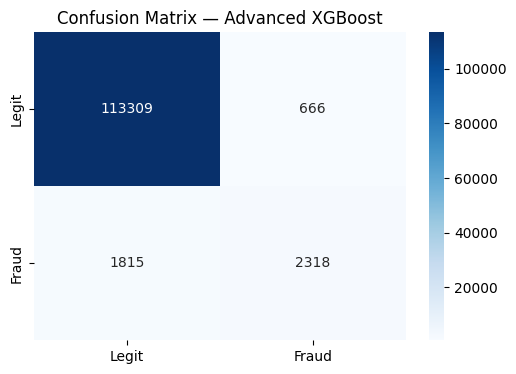

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc, confusion_matrix

# Load
train = pd.read_csv('../data/train_balanced.csv')
test = pd.read_csv('../data/test.csv')

X_train = train.drop(columns=['isFraud'])
y_train = train['isFraud']
X_test = test.drop(columns=['isFraud', 'TransactionID'], errors='ignore')
y_test = test['isFraud']

# KMeans Clusters
cluster_cols = ['TransactionAmt', 'Transaction_Hour']
kmeans = MiniBatchKMeans(n_clusters=10, random_state=42)
X_train['cluster_id'] = kmeans.fit_predict(X_train[cluster_cols])
X_test['cluster_id']  = kmeans.predict(X_test[cluster_cols])

# Train Champion XGBoost
model = XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.05, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

# Evaluate
probs = model.predict_proba(X_test)[:, 1]
preds = model.predict(X_test)

print("\n--- MODEL EVALUATION ---")
print(classification_report(y_test, preds))
print(f"ROC-AUC: {roc_auc_score(y_test, probs):.4f}")
precision, recall, _ = precision_recall_curve(y_test, probs)
print(f"PR-AUC: {auc(recall, precision):.4f}")

# Plot
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('Confusion Matrix — Advanced XGBoost')
plt.show()